# Predicting Profit: Machine Learning for Financial Analytics

This notebook builds and interprets machine learning models to predict profit and understand the key drivers of profitability in a financial dataset. The focus is on actionable business insights and model interpretability.

## 1. Load Cleaned Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
data_path = '../data/processed/financial_data_clean.csv'
df = pd.read_csv(data_path)
df.head()

,date,revenue,cost,units_sold,profit,margin,revenue_per_unit,year,month,region_North,region_South,region_West,product_Product B,product_Product C,product_Product D,product_Product E
0,2022-01-01,12000,7000,300,5000,0.416667,40.000000,2022,1,True,False,False,False,False,False,False
1,2022-01-01,9500,5800,250,3700,0.389474,38.000000,2022,1,True,False,False,True,False,False,False
2,2022-01-01,13500,7600,320,5900,0.437037,42.187500,2022,1,True,False,False,False,True,False,False
3,2022-01-01,11000,6500,280,4500,0.409091,39.285714,2022,1,True,False,False,False,False,True,False
4,2022-01-01,14500,8200,340,6300,0.434483,42.647059,2022,1,True,False,False,False,False,False,True


## 2. Define Features and Target

In [3]:
# Target variable
y = df['profit']
# Drop columns not used as features
X = df.drop(['profit', 'date'], axis=1)
X.head()

,revenue,cost,units_sold,margin,revenue_per_unit,year,month,region_North,region_South,region_West,product_Product B,product_Product C,product_Product D,product_Product E
0,12000,7000,300,0.416667,40.000000,2022,1,True,False,False,False,False,False,False
1,9500,5800,250,0.389474,38.000000,2022,1,True,False,False,True,False,False,False
2,13500,7600,320,0.437037,42.187500,2022,1,True,False,False,False,True,False,False
3,11000,6500,280,0.409091,39.285714,2022,1,True,False,False,False,False,True,False
4,14500,8200,340,0.434483,42.647059,2022,1,True,False,False,False,False,False,True


## 3. Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (384, 14), Test shape: (96, 14)


## 4. Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f'Linear Regression R2: {r2_lr:.3f}')
print(f'Linear Regression MAE: {mae_lr:.2f}')

Linear Regression R2: 1.000
Linear Regression MAE: 0.00


## 5. Linear Regression Coefficients and Interpretation

In [6]:
# Display coefficients with feature names
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
display(coef_df)

,Feature,Coefficient
0,revenue,1.000000e+00
1,cost,-1.000000e+00
3,margin,1.454630e-11
7,region_North,3.251830e-13
11,product_Product C,-2.417555e-13
9,region_West,1.737610e-13
8,region_South,1.537091e-13
4,revenue_per_unit,-1.233458e-13
12,product_Product D,-7.149403e-14
2,units_sold,-1.638880e-14


## 6. Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f'Random Forest R2: {r2_rf:.3f}')
print(f'Random Forest MAE: {mae_rf:.2f}')

Random Forest R2: 0.998
Random Forest MAE: 54.53


## 7. Model Comparison

In [8]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [r2_lr, r2_rf],
    'MAE': [mae_lr, mae_rf]
})
display(results)

,Model,R2,MAE
0,Linear Regression,1.000000,1.241081e-12
1,Random Forest,0.997606,5.453375e+01


## 8. Feature Importance (Random Forest)

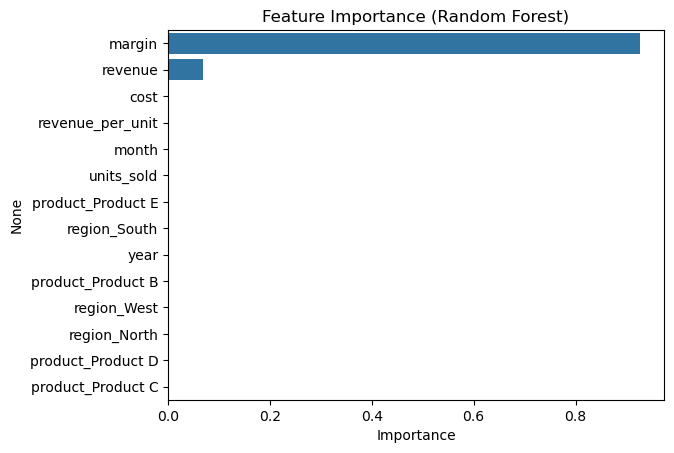

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 9. Business Insights and Interpretation

- **Key drivers of profitability**: The most important features identified by the models highlight which factors most influence profit.
- **Model comparison**: Comparing R2 and MAE helps select the best model for business use.
- **Interpretability**: Linear regression coefficients and random forest feature importances provide actionable insights for decision-makers.

*This notebook demonstrates a business-focused approach to machine learning, emphasizing interpretability and value for financial analytics.*